<a href="https://colab.research.google.com/github/tanveerratul34/Practice-/blob/main/Traffic_Parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

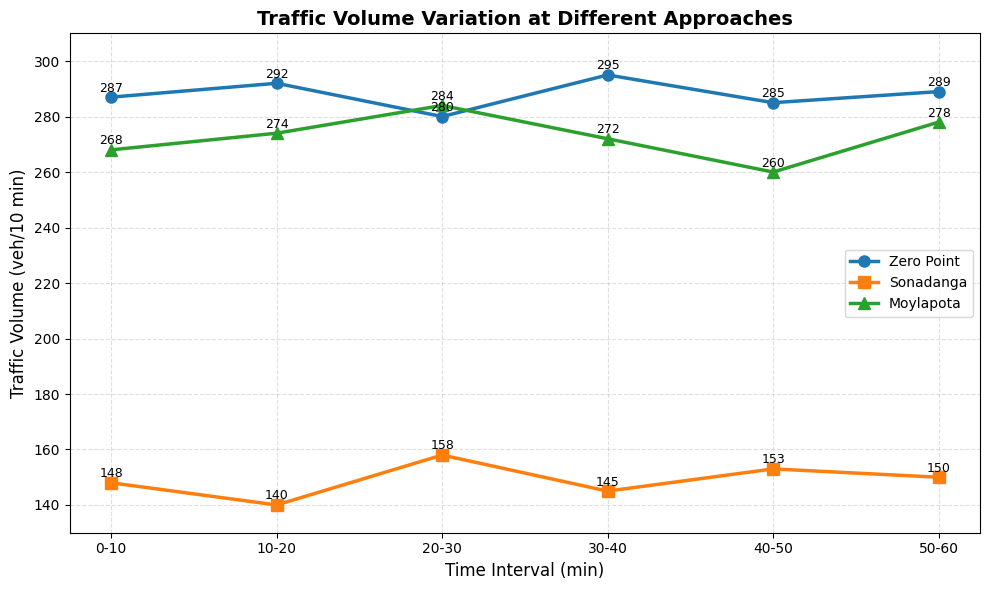

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Traffic Volume Data
# ==========================

time = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60']

zero_point = [287, 292, 280, 295, 285, 289]
sonadanga = [148, 140, 158, 145, 153, 150]
moylapota = [268, 274, 284, 272, 260, 278]

# ==========================
# Create Figure
# ==========================

plt.figure(figsize=(10, 6))

# Plot lines
plt.plot(time, zero_point,
         marker='o',
         linewidth=2.5,
         markersize=8,
         label='Zero Point')

plt.plot(time, sonadanga,
         marker='s',
         linewidth=2.5,
         markersize=8,
         label='Sonadanga')

plt.plot(time, moylapota,
         marker='^',
         linewidth=2.5,
         markersize=8,
         label='Moylapota')

# ==========================
# Add Data Labels
# ==========================

for x, y in zip(time, zero_point):
    plt.text(x, y + 2, str(y),
             ha='center',
             fontsize=9)

for x, y in zip(time, sonadanga):
    plt.text(x, y + 2, str(y),
             ha='center',
             fontsize=9)

for x, y in zip(time, moylapota):
    plt.text(x, y + 2, str(y),
             ha='center',
             fontsize=9)

# ==========================
# Formatting
# ==========================

plt.ylim(130, 310)

plt.xlabel('Time Interval (min)', fontsize=12)
plt.ylabel('Traffic Volume (veh/10 min)', fontsize=12)

plt.title('Traffic Volume Variation at Different Approaches',
          fontsize=14,
          fontweight='bold')

plt.grid(True,
         linestyle='--',
         alpha=0.4)

plt.legend(frameon=True,
           fontsize=10)

plt.tight_layout()

plt.show()

In [ ]:
# Generate some sample data for demonstration
np.random.seed(42)
data = {
    'Category': np.random.choice(['A', 'B', 'C', 'D'], size=100),
    'Value': np.random.normal(loc=50, scale=15, size=100)
}
df = pd.DataFrame(data)

print("Sample Data Head:")
display(df.head())

Sample Data Head:


,Category,Value
0,C,61.076999
1,D,52.570524
2,A,48.265276
3,C,45.483445
4,C,27.822170


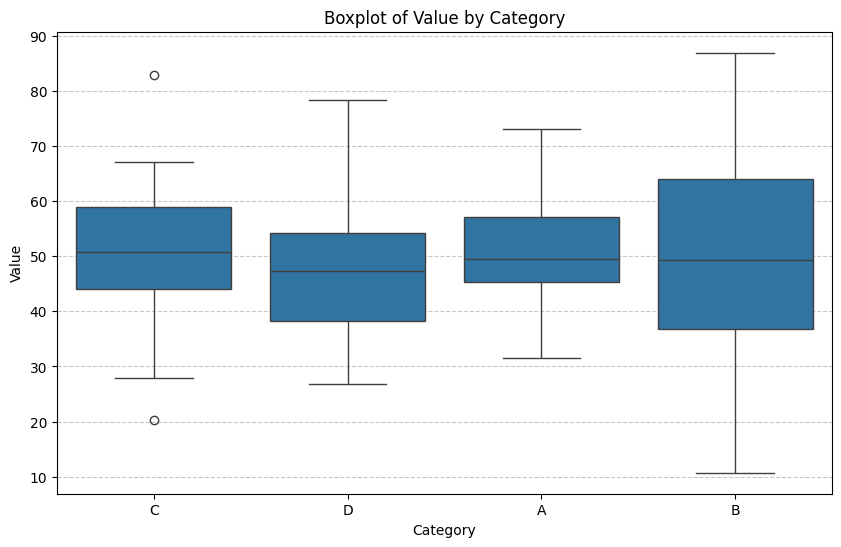

In [ ]:
# Create a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df)
plt.title('Boxplot of Value by Category')
plt.xlabel('Category')
plt.ylabel('Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from io import StringIO

# Your provided table data as a string
table_str = """
| Z-S | Z-M | S-M | S-Z | M-S | M-Z |
| --- | --- | --- | --- | --- | --- |
| 191.701 | 192.195 | 115.661 | 383.623 | 127.655 | 220.721 |
| 220.095 | 295.299 | 126.168 | 374.643 | 126.978 | 219.827 |
| 190.802 | 229.354 | 153.994 | 361.940 | 87.828 | 201.799 |
| 186.530 | 232.888 | 88.019 | 320.767 | 114.648 | 206.629 |
| 243.245 | 279.098 | 99.509 | 355.051 | 132.894 | 256.195 |
| 246.306 | 309.513 | 108.201 | 366.567 | 153.911 | 258.609 |
"""

# Read the table string into a DataFrame
# Use StringIO to treat the string as a file
# skip initial separator line
df_user = pd.read_csv(StringIO(table_str), sep='|', header=0, skipinitialspace=True)

# Clean up the DataFrame: remove the first empty column and the separator line
df_user = df_user.iloc[1:].dropna(axis=1, how='all')
df_user.columns = df_user.columns.str.strip()

# Convert values to numeric, coercing errors will turn non-numeric into NaN
for col in df_user.columns:
    df_user[col] = pd.to_numeric(df_user[col], errors='coerce')

print("DataFrame created from your table:")
display(df_user.head())

DataFrame created from your table:


,Z-S,Z-M,S-M,S-Z,M-S,M-Z
1,191.701,192.195,115.661,383.623,127.655,220.721
2,220.095,295.299,126.168,374.643,126.978,219.827
3,190.802,229.354,153.994,361.940,87.828,201.799
4,186.530,232.888,88.019,320.767,114.648,206.629
5,243.245,279.098,99.509,355.051,132.894,256.195


In [ ]:
# Melt the DataFrame to long format for easier plotting of multiple columns
df_user_melted = df_user.melt(var_name='Category', value_name='Value')

print("Melted DataFrame Head:")
display(df_user_melted.head())

Melted DataFrame Head:


,Category,Value
0,Z-S,191.701
1,Z-S,220.095
2,Z-S,190.802
3,Z-S,186.530
4,Z-S,243.245


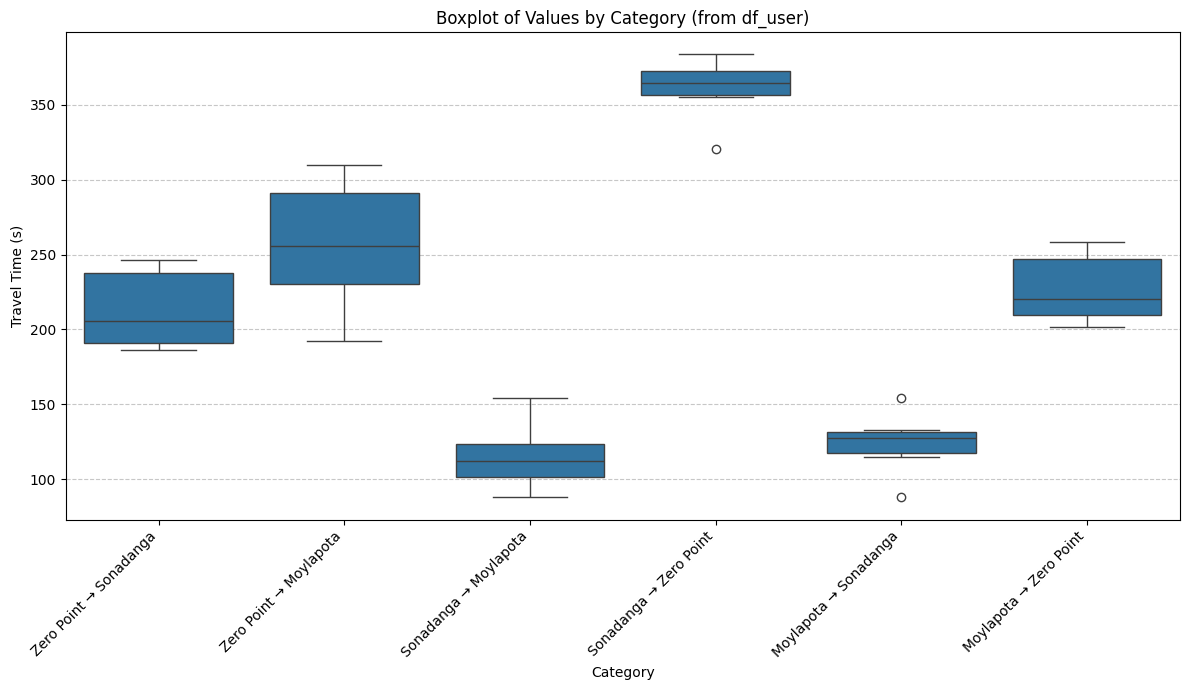

In [ ]:
# Create a boxplot using the melted DataFrame
plt.figure(figsize=(12, 7))
sns.boxplot(x='Category', y='Value', data=df_user_melted)
plt.title('Boxplot of Values by Category (from df_user)')
plt.xlabel('Category')
plt.ylabel('Travel Time (s)')

# Map current category names to full names for x-axis labels
category_mapping = {
    'Z-S': 'Zero Point \u2192 Sonadanga',
    'Z-M': 'Zero Point \u2192 Moylapota',
    'S-M': 'Sonadanga \u2192 Moylapota',
    'S-Z': 'Sonadanga \u2192 Zero Point',
    'M-S': 'Moylapota \u2192 Sonadanga',
    'M-Z': 'Moylapota \u2192 Zero Point'
}

# Apply the mapping to the x-axis tick labels
plt.xticks(ticks=range(len(df_user_melted['Category'].unique())),
           labels=[category_mapping[cat] for cat in df_user_melted['Category'].unique()],
           rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

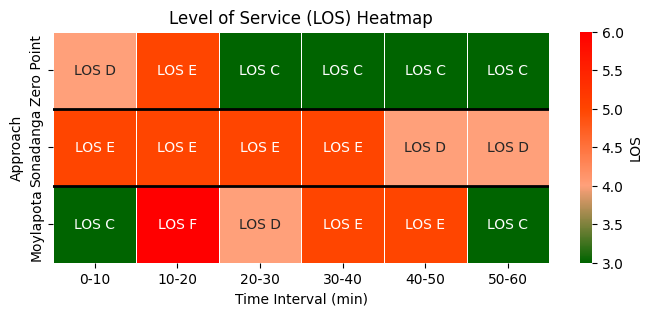

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

data = {
    '0-10':[4,5,3],
    '10-20':[5,5,6],
    '20-30':[3,5,4],
    '30-40':[3,5,5],
    '40-50':[3,4,5],
    '50-60':[3,4,3]
}

index=['Zero Point','Sonadanga','Moylapota']

df = pd.DataFrame(data,index=index)

plt.figure(figsize=(8,3))

# Define the custom colormap
# Values in df range from 3 to 6.
# User wants 1-3 light green to deep green (so deep green for 3),
# 4 light orange, 5 deep orange, 6 red.
# Normalize these points for the colormap based on the data range [3, 6]
colors = [
    (0.0, '#006400'),  # Deep green for value 3 (normalized to 0.0)
    (1/3, '#FFA07A'),  # Light orange for value 4 (normalized to 1/3)
    (2/3, '#FF4500'),  # Deep orange for value 5 (normalized to 2/3)
    (1.0, '#FF0000')   # Red for value 6 (normalized to 1.0)
]
custom_cmap = LinearSegmentedColormap.from_list("custom_los_cmap", colors)

# Create a DataFrame for annotations with 'LOS A' to 'LOS F'
los_map = {
    1: 'LOS A',
    2: 'LOS B',
    3: 'LOS C',
    4: 'LOS D',
    5: 'LOS E',
    6: 'LOS F'
}
df_annotations = df.map(lambda x: los_map.get(x, str(x))) # Apply the mapping using df.map

ax = sns.heatmap(df,
            annot=df_annotations, # Use the custom annotation DataFrame
            fmt="",               # Use empty format string because we provide strings
            cmap=custom_cmap,     # Use the custom colormap
            vmin=3,               # Set vmin to 3 to map deep green to 3
            vmax=6,               # Set vmax to 6 to map red to 6
            cbar_kws={'label':'LOS'},
            linewidths=0.5)

# Add horizontal lines to separate the rows on the y-axis
# The lines should be placed at y=0.5, y=1.5, etc., relative to the heatmap's internal indexing
for i in range(len(df) - 1):
    ax.axhline(y=i + 1, color='black', linewidth=2)

plt.title('Level of Service (LOS) Heatmap')
plt.xlabel('Time Interval (min)')
plt.ylabel('Approach')

plt.show()

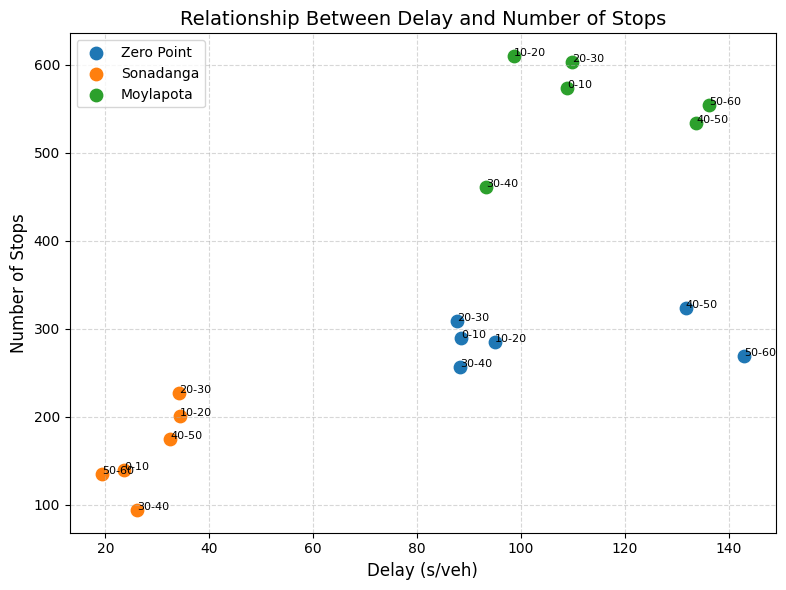

In [ ]:
import matplotlib.pyplot as plt

# Data
time_intervals = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60']

# Zero Point
delay_zp = [88.4871, 94.9757, 87.7014, 88.3729, 131.72, 142.974]
stops_zp = [290, 285, 309, 257, 324, 269]

# Sonadanga
delay_s = [23.6641, 34.3937, 34.2466, 26.0407, 32.4515, 19.3172]
stops_s = [140, 201, 227, 94, 175, 135]

# Moylapota
delay_m = [108.869, 98.6358, 109.871, 93.3317, 133.777, 136.196]
stops_m = [574, 610, 603, 461, 534, 554]

# Create figure
plt.figure(figsize=(8,6))

# Scatter plots
plt.scatter(delay_zp, stops_zp, label='Zero Point', s=80)
plt.scatter(delay_s, stops_s, label='Sonadanga', s=80)
plt.scatter(delay_m, stops_m, label='Moylapota', s=80)

# Add time labels
for i, txt in enumerate(time_intervals):
    plt.annotate(txt, (delay_zp[i], stops_zp[i]), fontsize=8)

for i, txt in enumerate(time_intervals):
    plt.annotate(txt, (delay_s[i], stops_s[i]), fontsize=8)

for i, txt in enumerate(time_intervals):
    plt.annotate(txt, (delay_m[i], stops_m[i]), fontsize=8)

# Labels and title
plt.xlabel('Delay (s/veh)', fontsize=12)
plt.ylabel('Number of Stops', fontsize=12)
plt.title('Relationship Between Delay and Number of Stops', fontsize=14)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Calculate correlation for Zero Point
corr_zp = np.corrcoef(delay_zp, stops_zp)[0, 1]
print(f"Correlation between Delay and Stops for Zero Point: {corr_zp:.4f}")

# Calculate correlation for Sonadanga
corr_s = np.corrcoef(delay_s, stops_s)[0, 1]
print(f"Correlation between Delay and Stops for Sonadanga: {corr_s:.4f}")

# Calculate correlation for Moylapota
corr_m = np.corrcoef(delay_m, stops_m)[0, 1]
print(f"Correlation between Delay and Stops for Moylapota: {corr_m:.4f}")

Correlation between Delay and Stops for Zero Point: 0.1250
Correlation between Delay and Stops for Sonadanga: 0.7731
Correlation between Delay and Stops for Moylapota: 0.0755


In [ ]:
import pandas as pd

# Create a dictionary to hold the data for each location
comparison_data = {
    'Time Interval': time_intervals,
    'Zero Point Delay': delay_zp,
    'Zero Point Stops': stops_zp,
    'Sonadanga Delay': delay_s,
    'Sonadanga Stops': stops_s,
    'Moylapota Delay': delay_m,
    'Moylapota Stops': stops_m
}

# Create a DataFrame from the dictionary
df_comparison = pd.DataFrame(comparison_data)

# Display the DataFrame
display(df_comparison)

,Time Interval,Zero Point Delay,Zero Point Stops,Sonadanga Delay,Sonadanga Stops,Moylapota Delay,Moylapota Stops
0,0-10,88.4871,290,23.6641,140,108.8690,574
1,10-20,94.9757,285,34.3937,201,98.6358,610
2,20-30,87.7014,309,34.2466,227,109.8710,603
3,30-40,88.3729,257,26.0407,94,93.3317,461
4,40-50,131.7200,324,32.4515,175,133.7770,534
5,50-60,142.9740,269,19.3172,135,136.1960,554


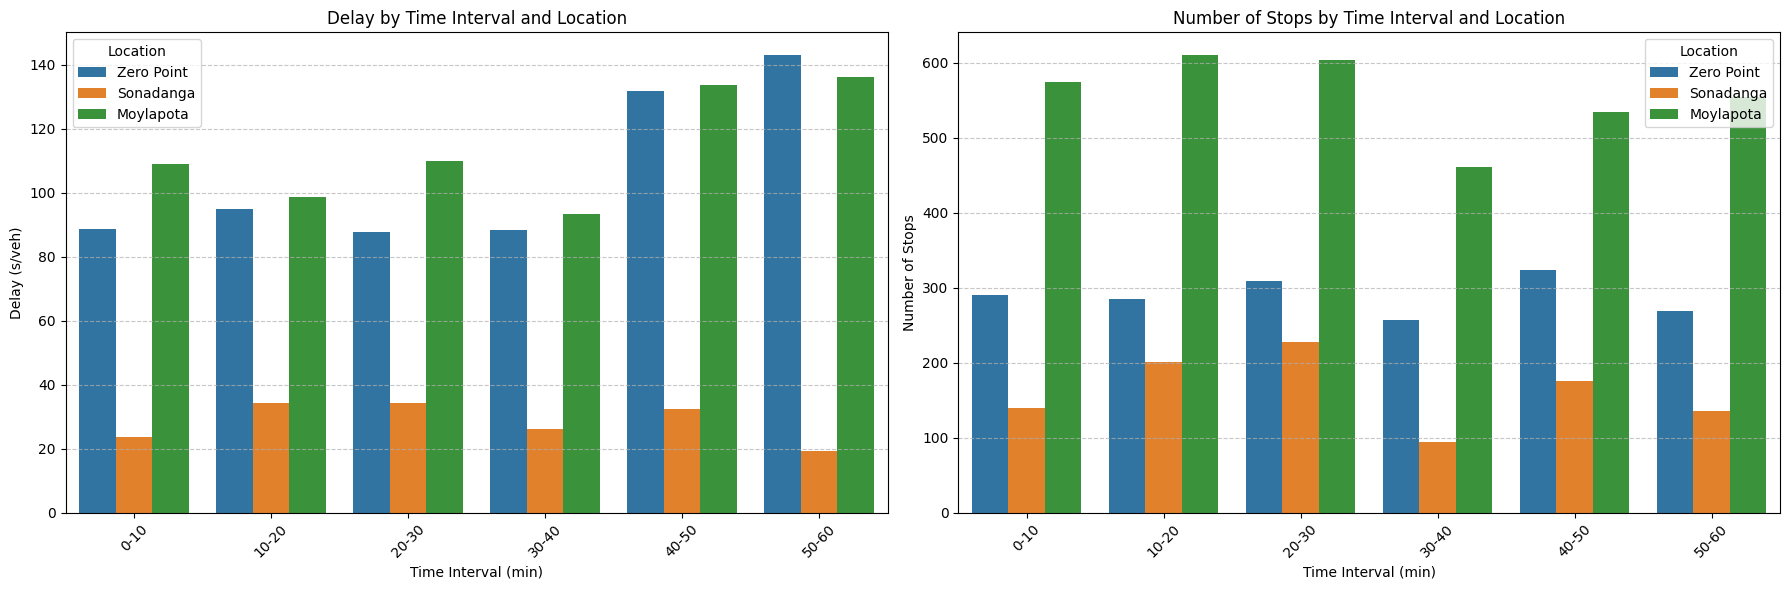

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Melt the DataFrame to a long format suitable for grouped bar charts
df_long = df_comparison.melt(id_vars=['Time Interval'], var_name='Metric', value_name='Value')

# Extract 'Location' and 'Metric Type' from the 'Metric' column
def parse_metric(metric_str):
    parts = metric_str.rsplit(' ', maxsplit=1) # Split from right, once
    metric_type = parts[-1] # 'Delay' or 'Stops'
    location = ' '.join(parts[:-1]) # Join remaining parts to form location
    return location, metric_type

df_long[['Location', 'Metric_Type']] = df_long['Metric'].apply(lambda x: pd.Series(parse_metric(x)))

# Create two subplots: one for Delay and one for Stops
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Plot for Delay
sns.barplot(x='Time Interval', y='Value', hue='Location', data=df_long[df_long['Metric_Type'] == 'Delay'], ax=axes[0])
axes[0].set_title('Delay by Time Interval and Location')
axes[0].set_xlabel('Time Interval (min)')
axes[0].set_ylabel('Delay (s/veh)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Stops
sns.barplot(x='Time Interval', y='Value', hue='Location', data=df_long[df_long['Metric_Type'] == 'Stops'], ax=axes[1])
axes[1].set_title('Number of Stops by Time Interval and Location')
axes[1].set_xlabel('Time Interval (min)')
axes[1].set_ylabel('Number of Stops')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

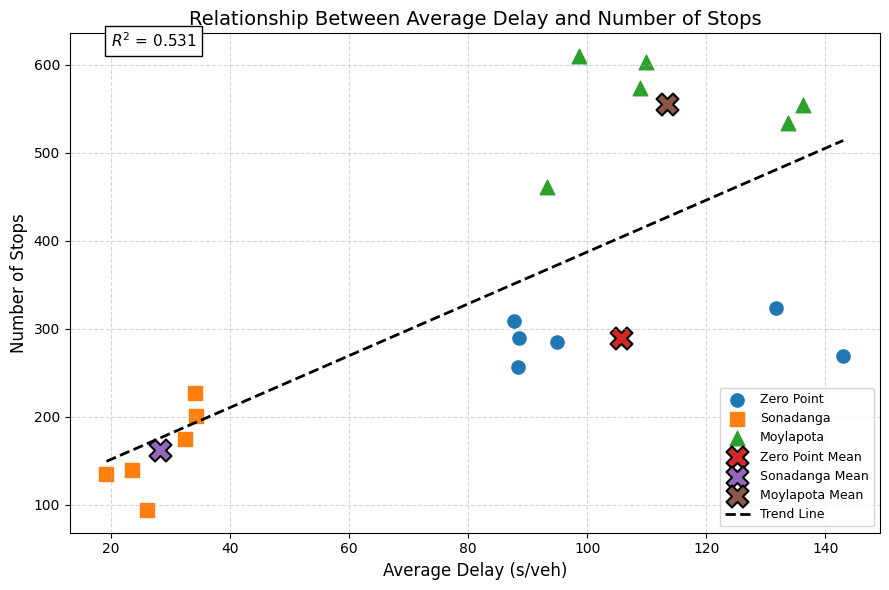

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# Data
# ==========================

# Zero Point
delay_zp = [88.4871, 94.9757, 87.7014, 88.3729, 131.72, 142.974]
stops_zp = [290, 285, 309, 257, 324, 269]

# Sonadanga
delay_s = [23.6641, 34.3937, 34.2466, 26.0407, 32.4515, 19.3172]
stops_s = [140, 201, 227, 94, 175, 135]

# Moylapota
delay_m = [108.869, 98.6358, 109.871, 93.3317, 133.777, 136.196]
stops_m = [574, 610, 603, 461, 534, 554]

# ==========================
# Figure
# ==========================

plt.figure(figsize=(9,6))

# Scatter points
plt.scatter(delay_zp, stops_zp,
            marker='o',
            s=90,
            label='Zero Point')

plt.scatter(delay_s, stops_s,
            marker='s',
            s=90,
            label='Sonadanga')

plt.scatter(delay_m, stops_m,
            marker='^',
            s=110,
            label='Moylapota')

# ==========================
# Centroids (Means)
# ==========================

plt.scatter(np.mean(delay_zp),
            np.mean(stops_zp),
            marker='X',
            s=250,
            edgecolors='black',
            linewidth=1.5,
            label='Zero Point Mean')

plt.scatter(np.mean(delay_s),
            np.mean(stops_s),
            marker='X',
            s=250,
            edgecolors='black',
            linewidth=1.5,
            label='Sonadanga Mean')

plt.scatter(np.mean(delay_m),
            np.mean(stops_m),
            marker='X',
            s=250,
            edgecolors='black',
            linewidth=1.5,
            label='Moylapota Mean')

# ==========================
# Trend Line
# ==========================

delay_all = delay_zp + delay_s + delay_m
stops_all = stops_zp + stops_s + stops_m

coeffs = np.polyfit(delay_all, stops_all, 1)
trendline = np.poly1d(coeffs)

x_line = np.linspace(min(delay_all),
                     max(delay_all),
                     200)

y_line = trendline(x_line)

plt.plot(x_line,
         y_line,
         '--',
         color='black',
         linewidth=2,
         label='Trend Line')

# ==========================
# R²
# ==========================

y_pred = trendline(delay_all)

ss_res = np.sum((np.array(stops_all) - y_pred) ** 2)
ss_tot = np.sum((np.array(stops_all) - np.mean(stops_all)) ** 2)

r2 = 1 - (ss_res / ss_tot)

plt.text(
    20,
    620,
    f'$R^2$ = {r2:.3f}',
    fontsize=11,
    bbox=dict(facecolor='white',
              edgecolor='black')
)

# ==========================
# Formatting
# ==========================

plt.xlabel('Average Delay (s/veh)', fontsize=12)
plt.ylabel('Number of Stops', fontsize=12)

plt.title('Relationship Between Average Delay and Number of Stops',
          fontsize=14)

plt.grid(True,
         linestyle='--',
         alpha=0.5)

plt.legend(loc='best',
           fontsize=9)

plt.tight_layout()

plt.show()

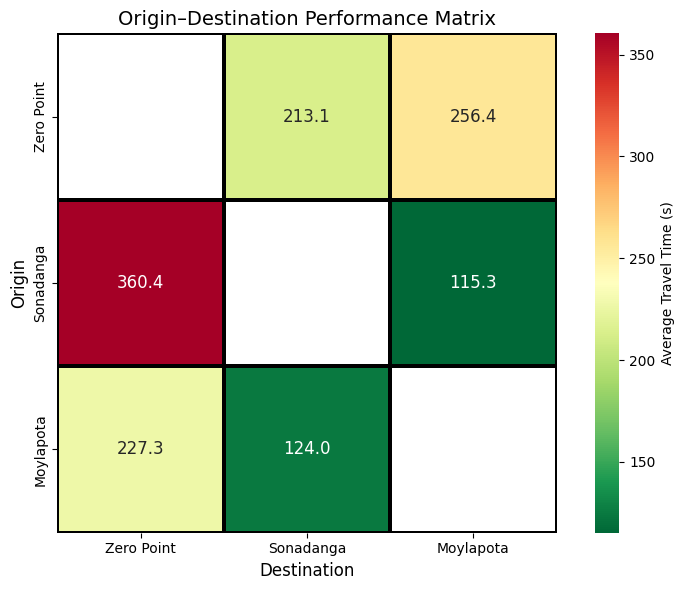

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Average travel times (s)
od_matrix = [
    [np.nan, 213.11, 256.39],   # Zero Point
    [360.43, np.nan, 115.26],   # Sonadanga
    [227.30, 123.99, np.nan]    # Moylapota
]

origins = ['Zero Point', 'Sonadanga', 'Moylapota']
destinations = ['Zero Point', 'Sonadanga', 'Moylapota']

# Create DataFrame
df = pd.DataFrame(
    od_matrix,
    index=origins,
    columns=destinations
)

# Create heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',   # Green = low travel time, Red = high travel time
    linewidths=1.5,
    linecolor='black',
    square=True,
    annot_kws={"size":12},
    cbar_kws={'label':'Average Travel Time (s)'}
)

plt.title('Origin–Destination Performance Matrix', fontsize=14)
plt.xlabel('Destination', fontsize=12)
plt.ylabel('Origin', fontsize=12)

plt.tight_layout()
plt.show()

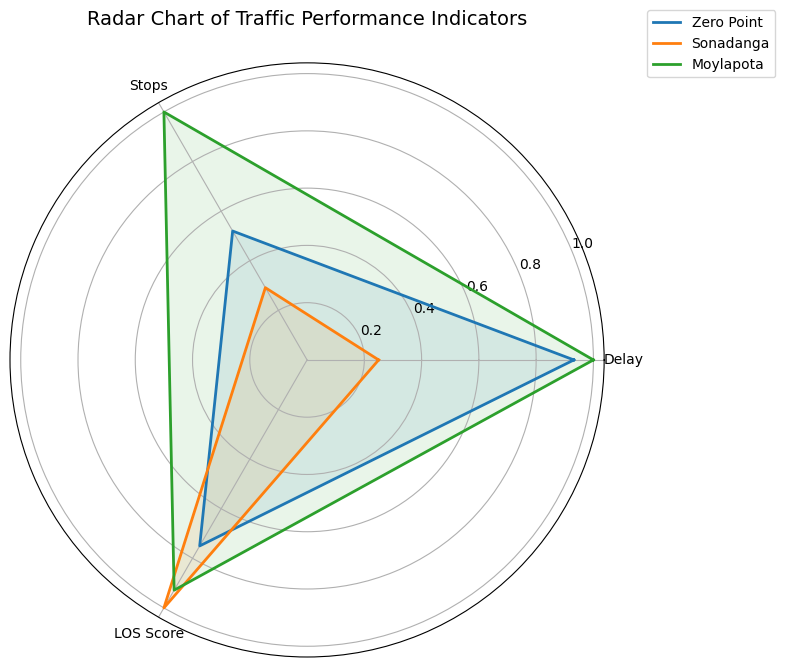

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Added pandas import

# Definitions for delay and stops from cell 732c04a8
delay_zp = [88.4871, 94.9757, 87.7014, 88.3729, 131.72, 142.974]
stops_zp = [290, 285, 309, 257, 324, 269]
delay_s = [23.6641, 34.3937, 34.2466, 26.0407, 32.4515, 19.3172]
stops_s = [140, 201, 227, 94, 175, 135]
delay_m = [108.869, 98.6358, 109.871, 93.3317, 133.777, 136.196]
stops_m = [574, 610, 603, 461, 534, 554]

# Definition for df (LOS scores) from cell 18633e6b
data_los = {
    '0-10':[4,5,3],
    '10-20':[5,5,6],
    '20-30':[3,5,4],
    '30-40':[3,5,5],
    '40-50':[3,4,5],
    '50-60':[3,4,3]
}
index_los=['Zero Point','Sonadanga','Moylapota']
df = pd.DataFrame(data_los,index=index_los)


# Categories for the radar chart
categories = ['Delay', 'Stops', 'LOS Score']
N = len(categories)

# Calculate values for each location dynamically
# Using previously defined delay and stops lists (delay_zp, stops_zp, etc.)
# And the 'df' from the LOS Heatmap cell (18633e6b) for LOS Scores

# Zero Point
zero_point_delay = np.mean(delay_zp)
zero_point_stops = np.mean(stops_zp)
zero_point_los = df.loc['Zero Point'].mean()
zero_point = [zero_point_delay, zero_point_stops, zero_point_los]

# Sonadanga
sonadanga_delay = np.mean(delay_s)
sonadanga_stops = np.mean(stops_s)
sonadanga_los = df.loc['Sonadanga'].mean()
sonadanga = [sonadanga_delay, sonadanga_stops, sonadanga_los]

# Moylapota
moylapota_delay = np.mean(delay_m)
moylapota_stops = np.mean(stops_m)
moylapota_los = df.loc['Moylapota'].mean()
moylapota = [moylapota_delay, moylapota_stops, moylapota_los]

# Normalize data (important for radar charts)
data = np.array([zero_point, sonadanga, moylapota])

# Normalize each column independently (e.g., all delays relative to max delay, all stops relative to max stops)
normalized = data / data.max(axis=0)

zp = normalized[0].tolist()
sd = normalized[1].tolist()
mp = normalized[2].tolist()

# Close polygons by repeating the first value to connect the radar chart
zp += zp[:1]
sd += sd[:1]
mp += mp[:1]

# Set up angles for the radar chart
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Plotting the radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, zp, linewidth=2, label='Zero Point')
ax.fill(angles, zp, alpha=0.1)

ax.plot(angles, sd, linewidth=2, label='Sonadanga')
ax.fill(angles, sd, alpha=0.1)

ax.plot(angles, mp, linewidth=2, label='Moylapota')
ax.fill(angles, mp, alpha=0.1)

# Set x-tick labels to categories
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title('Radar Chart of Traffic Performance Indicators', size=14, y=1.05)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

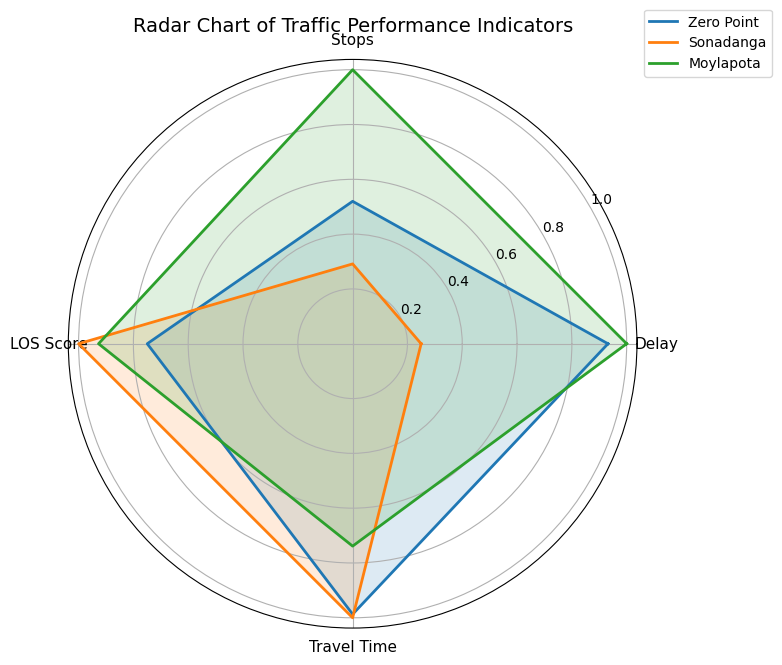

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Categories
categories = ['Delay', 'Stops', 'LOS Score', 'Travel Time']
N = len(categories)

# Raw Data
zero_point = [105.71, 289, 3.50, 234.75]
sonadanga = [28.36, 162, 4.67, 237.85]
moylapota = [113.45, 556, 4.33, 175.65]

# Normalize each indicator
data = np.array([zero_point, sonadanga, moylapota])
normalized = data / data.max(axis=0)

zp = normalized[0].tolist()
sd = normalized[1].tolist()
mp = normalized[2].tolist()

# Close polygons
zp += zp[:1]
sd += sd[:1]
mp += mp[:1]

# Angles
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Figure
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

# Zero Point
ax.plot(angles, zp, linewidth=2, label='Zero Point')
ax.fill(angles, zp, alpha=0.15)

# Sonadanga
ax.plot(angles, sd, linewidth=2, label='Sonadanga')
ax.fill(angles, sd, alpha=0.15)

# Moylapota
ax.plot(angles, mp, linewidth=2, label='Moylapota')
ax.fill(angles, mp, alpha=0.15)

# Axis Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)

# Radial labels
ax.set_rlabel_position(30)

# Title
plt.title(
    'Radar Chart of Traffic Performance Indicators',
    size=14,
    pad=20
)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.25, 1.1)
)

plt.tight_layout()
plt.show()

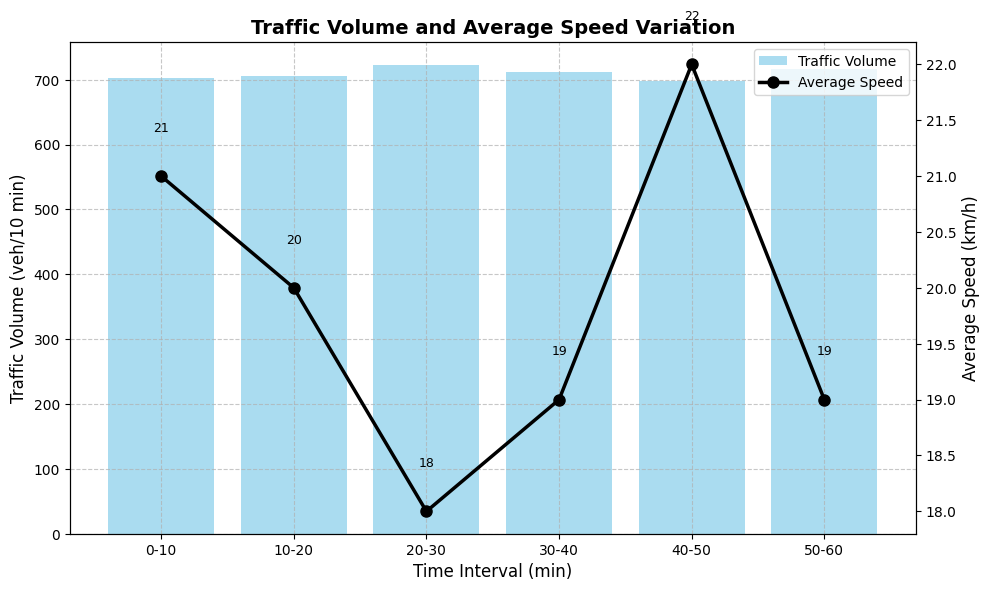

In [ ]:
import matplotlib.pyplot as plt

# Data for plotting
time = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60'] # Time intervals in minutes
volume = [703, 706, 722, 712, 698, 717] # Traffic volume (vehicles per 10 minutes)
speed = [21, 20, 18, 19, 22, 19] # Average speed (km/h)

# Create a figure and a primary axes (ax1) for the volume plot
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot Traffic Volume as a bar chart on the left y-axis (ax1)
bars = ax1.bar(time, volume,
               color='skyblue',
               alpha=0.7,
               label='Traffic Volume')

# Set labels and title for the primary y-axis (volume)
ax1.set_xlabel('Time Interval (min)', fontsize=12)
ax1.set_ylabel('Traffic Volume (veh/10 min)', fontsize=12, color='black') # Changed color to black
ax1.tick_params(axis='y', labelcolor='black') # Changed label color to black

# Add volume data labels on top of the bars (Removed as per user request)
# for bar in bars:
#     height = bar.get_height()
#     ax1.text(bar.get_x() + bar.get_width()/2,
#              height + 3, # Offset label slightly above the bar
#              f'{height}',
#              ha='center',
#              fontsize=9)

# Create a secondary y-axis (ax2) that shares the same x-axis as ax1
ax2 = ax1.twinx()

# Plot Average Speed as a line chart on the right y-axis (ax2)
ax2.plot(time, speed,
         color='black', # Changed color to black
         marker='o',
         linewidth=2.5,
         markersize=8,
         label='Average Speed')

# Set label and title for the secondary y-axis (speed)
ax2.set_ylabel('Average Speed (km/h)', fontsize=12, color='black') # Changed color to black
ax2.tick_params(axis='y', labelcolor='black') # Changed label color to black

# Add speed data labels next to the points on the line plot
for i, s in enumerate(speed):
    ax2.text(i, s + 0.4, # Offset label slightly above the point
             str(s),
             ha='center',
             fontsize=9,
             color='black') # Changed color to black

# Set the overall title for the plot
plt.title('Traffic Volume and Average Speed Variation', fontsize=14, fontweight='bold')

# Combine legends from both axes into a single legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

# Add a grid for better readability
ax1.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
plt.show()

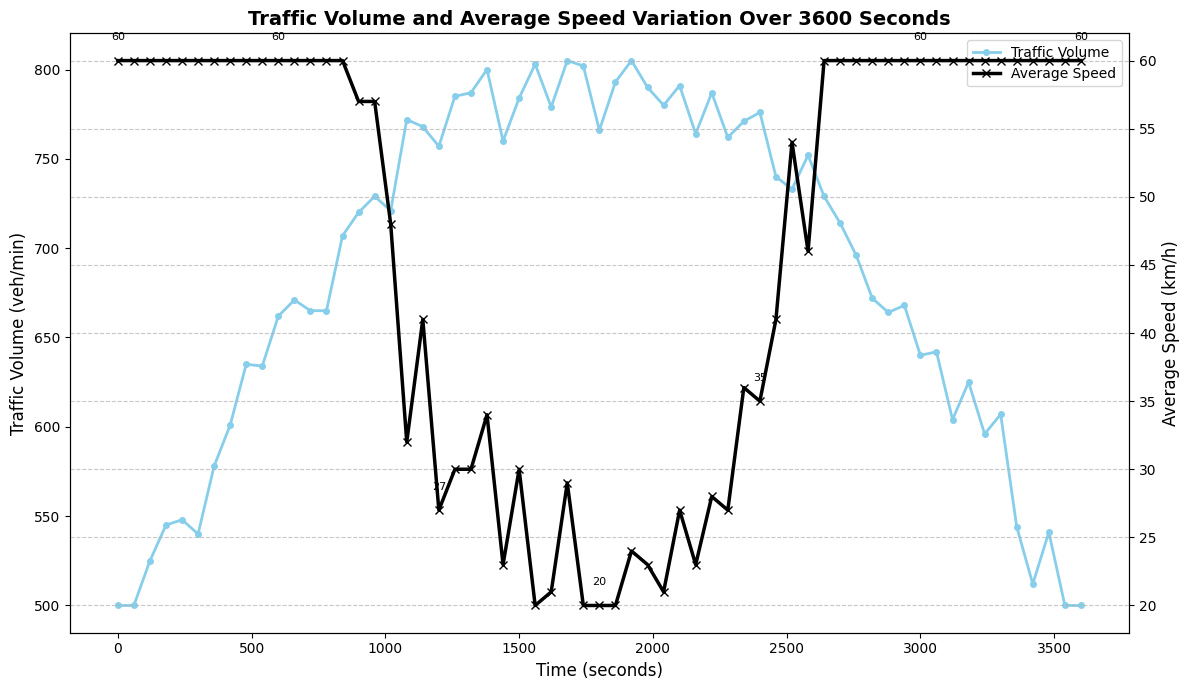

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate time points for 3600 seconds (60 minutes) at 1-minute intervals
time_seconds = np.arange(0, 3600 + 60, 60) # 0 to 3600 seconds, step 60 (1 minute)
time_minutes_labels = [f'{i // 60}-{i // 60 + 1}' for i in time_seconds[:-1]] # Labels for 1-minute intervals
time_minutes_labels.append('60-61') # Add the last label for 60-61 min

# Generate synthetic traffic volume data (e.g., slight variation around a mean)
# Let's create some 'reasonable' fluctuations, perhaps a bit higher in the middle
volume_base = 700
volume_noise = np.random.normal(0, 15, len(time_seconds))
# Add a gentle curve to volume data
volume_curve = -0.0001 * (time_seconds - 1800)**2 + 100 # Peak at 30 min (1800s)
volume = (volume_base + volume_noise + volume_curve).astype(int)
volume = np.clip(volume, 500, 900) # Ensure volume stays within a sensible range

# Generate synthetic speed data (e.g., varying between 20-50 km/h)
speed_base = 35
speed_noise = np.random.normal(0, 5, len(time_seconds))
# Add an inverse curve to speed data (speed might drop when volume is high)
speed_curve = 0.00005 * (time_seconds - 1800)**2 - 15
speed = (speed_base + speed_noise + speed_curve).astype(int)
speed = np.clip(speed, 20, 60) # Ensure speed stays within a sensible range

# Create figure
fig, ax1 = plt.subplots(figsize=(12, 7))

# Left Y-axis: Traffic Volume (using line plot for 'curve' interpretation)
ax1.plot(time_seconds, volume,
         color='skyblue',
         linewidth=2,
         marker='o',
         markersize=4,
         label='Traffic Volume')

ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_ylabel('Traffic Volume (veh/min)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Right Y-axis: Speed
ax2 = ax1.twinx()

ax2.plot(time_seconds, speed,
         color='black', # Black line as requested
         marker='x',
         linewidth=2.5,
         markersize=6,
         label='Average Speed')

ax2.set_ylabel('Average Speed (km/h)', fontsize=12, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add speed labels (black as requested)
for i, s_val in enumerate(speed):
    if i % 10 == 0: # Only label every 10th point for readability
        ax2.text(time_seconds[i], s_val + 1.5,
                 str(s_val),
                 ha='center',
                 fontsize=8,
                 color='black')

# Title
plt.title('Traffic Volume and Average Speed Variation Over 3600 Seconds', fontsize=14, fontweight='bold')

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2,
           labels + labels2,
           loc='upper right')

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()